<a href="https://colab.research.google.com/github/rozario-lamperouge/Machine-Learning-Course/blob/master/Ensemble_Learning/01_Ensemble_Learning_Methods_BLANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Learning Methods
### A hands-on 2-hour workshop

> **The core idea in one line:** a crowd of *diverse, better-than-random* models is almost always more accurate and more stable than any single model in that crowd.

---



## How to use this notebook
- Run cells **top to bottom** (`Shift + Enter`). Every section is self-contained after Section 2.
- Every concept has a **diagram or plot** — read the picture first, then the code.
- Cells marked 🧪 are **experiments**: change a number and re-run to see the effect.
- Cells marked 💡 contain the **takeaway** you should remember.

**Datasets used (all open source, downloaded automatically):**
1. *Breast Cancer Wisconsin (Diagnostic)* — bundled with scikit-learn (UCI ML Repository).
2. *Adult / Census Income* — UCI ML Repository, loaded from a public GitHub mirror.

---
# 0. Setup

Colab already has everything we need. This cell just imports and fixes the random seed so **your numbers match the ones on screen**.

In [ ]:
# If any import fails in a fresh environment, uncomment:
# !pip install -q scikit-learn pandas matplotlib seaborn

import warnings, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
sns.set_palette("Set2")

import sklearn
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("numpy      :", np.__version__)
print("pandas     :", pd.__version__)
print("sklearn    :", sklearn.__version__)
print("\nSetup complete. Random seed =", RANDOM_STATE)

numpy      : 2.0.2
pandas     : 2.2.2
sklearn    : 1.6.1

Setup complete. Random seed = 42


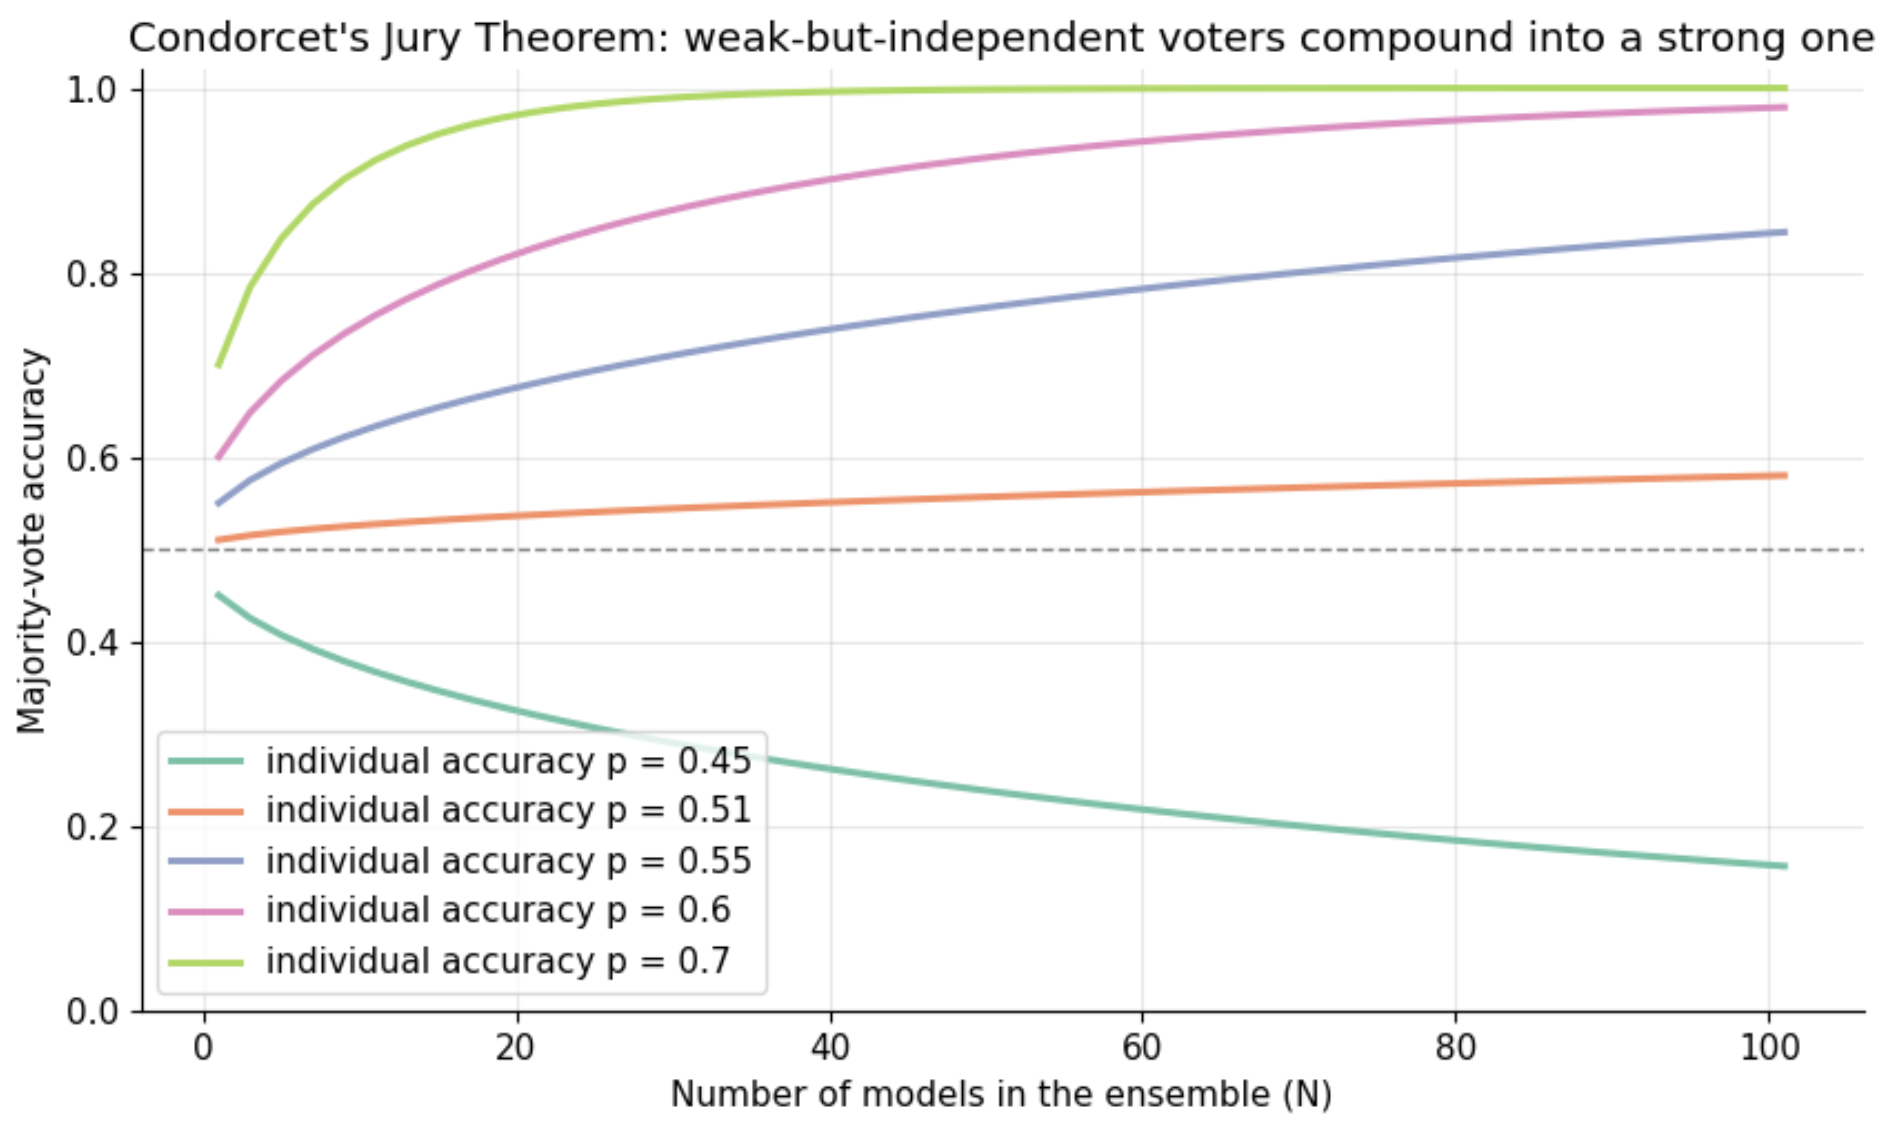


💡 **Takeaway 1:** 100 models that are each only 60% accurate vote their way to ~98% accuracy —
**but only if their errors are independent.**

That word *independent* is the catch. Real models trained on the same data make **correlated** mistakes.
So every ensemble method you will learn today is really an answer to one question:

> ### *"How do I make my models disagree with each other in useful ways?"*

| Method | How it creates diversity |
|--------|--------------------------|
| **Voting** | Use fundamentally different algorithms (tree, SVM, kNN, logistic regression) |
| **Bagging** | Train each model on a different random **sample of rows** |
| **Random Forest** | Different rows **and** a different random subset of **columns** at every split |
| **Extra Trees** | Rows, columns **and** random split thresholds |
| **Boosting** | Each model is deliberately trained on what the previous ones got **wrong** |
| **Stacking** | Let a *meta-model* learn who to trust, and when |

## 1.2 The bias–variance decomposition

For squared error, the expected test error of a model decomposes as:

$$\mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}[\hat f(x)]^2}_{\text{wrong assumptions}} + \underbrace{\text{Var}[\hat f(x)]}_{\text{sensitivity to the training set}} + \underbrace{\sigma^2}_{\text{irreducible noise}}$$

This is the single most useful mental model for choosing an ensemble:

- **Bagging / Random Forest / Extra Trees** attack **variance**. Use deep, low-bias, overfit-prone base models (fully grown trees) and average the noise away.
- **Boosting** attacks **bias**. Use shallow, high-bias, weak base models (stumps) and add them up until they fit.

Here is the whole family on one page.

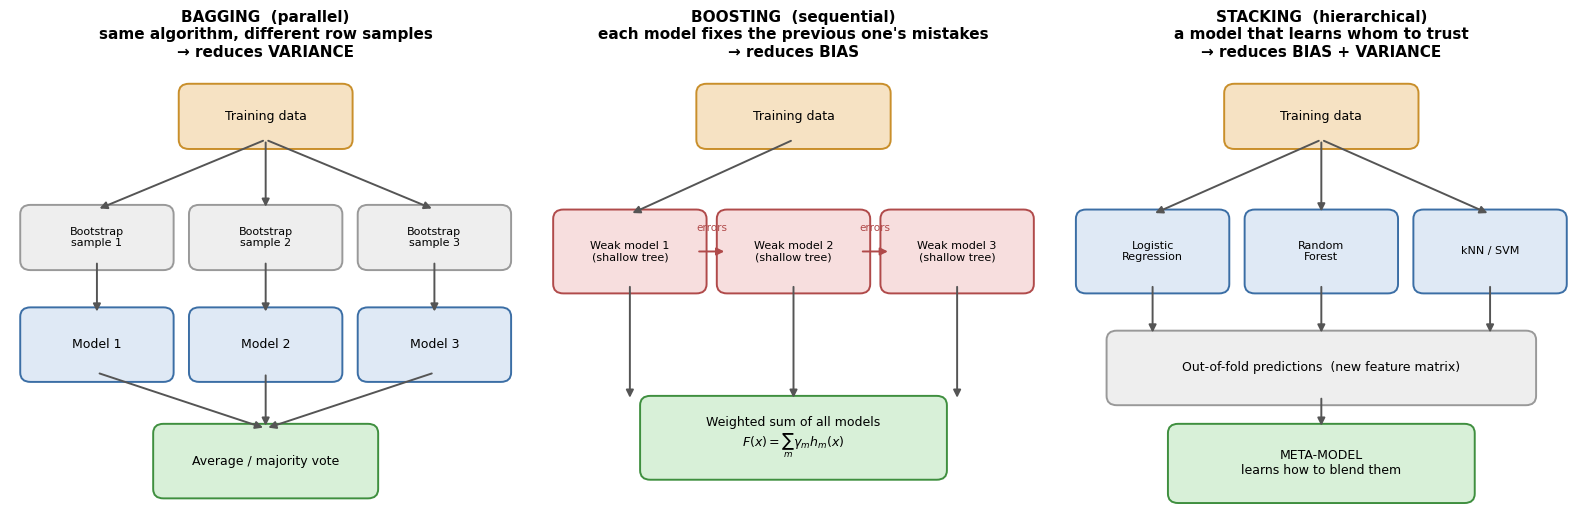

---
# 2. The dataset & our evaluation harness

We use the **Breast Cancer Wisconsin (Diagnostic)** dataset from the UCI ML Repository, which ships
inside scikit-learn (no download needed).

- **569 patients**, **30 numeric features** computed from a digitised image of a fine-needle aspirate
  of a breast mass (radius, texture, perimeter, area, smoothness, ... each as mean / standard error / worst).
- **Target:** `1 = benign`, `0 = malignant`.

It is small, clean and numeric — perfect for *seeing* what each algorithm does without waiting on compute.
Section 10 moves to a big messy dataset with text columns and missing values.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

print("Shape :", X.shape)
print("Target:", dict(zip(data.target_names, np.bincount(y))))
X.head()

Shape : (569, 30)
Target: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


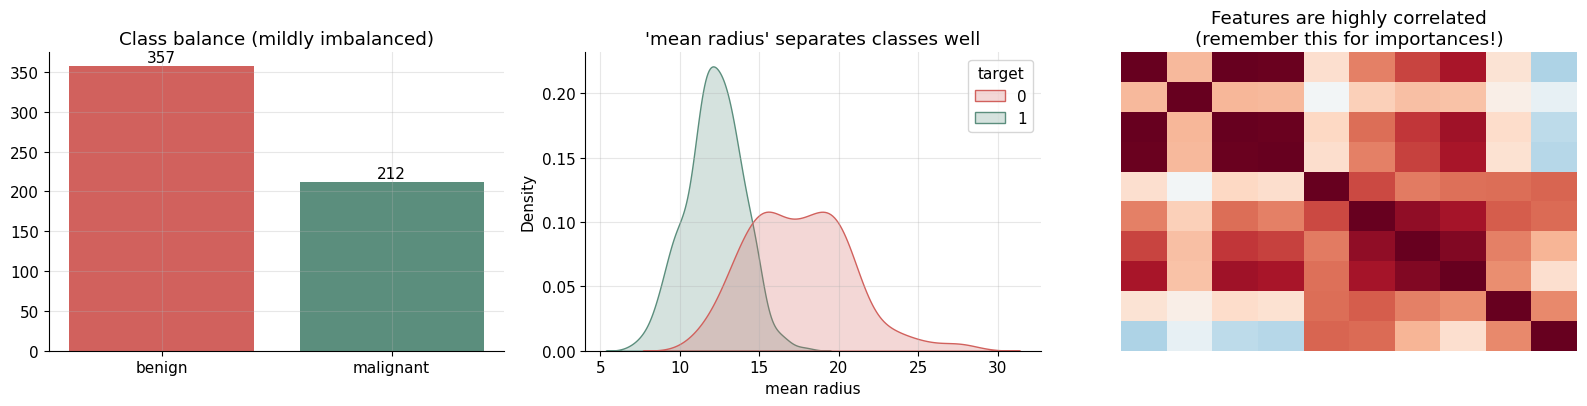

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# class balance
counts = pd.Series(y).map({0: "malignant", 1: "benign"}).value_counts()
axes[0].bar(counts.index, counts.values, color=["#d1615d", "#5b8e7d"])
axes[0].set_title("Class balance (mildly imbalanced)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center")

# a couple of features by class
sns.kdeplot(data=X.assign(target=y), x="mean radius", hue="target", fill=True, ax=axes[1],
            common_norm=False, palette=["#d1615d", "#5b8e7d"])
axes[1].set_title("'mean radius' separates classes well")

# correlation heat map of first 10 features
sns.heatmap(X.iloc[:, :10].corr(), cmap="RdBu_r", center=0, ax=axes[2],
            cbar=False, xticklabels=False, yticklabels=False)
axes[2].set_title("Features are highly correlated\n(remember this for importances!)")

plt.tight_layout();

### Our evaluation harness

Every model in this notebook goes through the **same** function so comparisons are fair.
We report **accuracy, ROC-AUC and fit time**, and keep the results in a global table.

ROC-AUC - Area Under the Receiver Operating Characteristic Curve

In [ ]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} rows   |   Test: {X_test.shape[0]} rows")

Train: 426 rows   |   Test: 143 rows


In [ ]:
RESULTS = {}   # name -> dict of metrics

def evaluate(model, name, X_tr=X_train, y_tr=y_train, X_te=X_test, y_te=y_test, store=True):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    fit_time = time.time() - t0

    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)

    try:
        proba = model.predict_proba(X_te)[:, 1]
        auc = roc_auc_score(y_te, proba)
    except AttributeError:                      # e.g. hard voting has no proba
        auc = np.nan

    cv = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(5, shuffle=True,
                         random_state=RANDOM_STATE), scoring="accuracy")

    if store:
        RESULTS[name] = {"test_accuracy": acc, "test_auc": auc,
                         "cv_mean": cv.mean(), "cv_std": cv.std(), "fit_time_s": fit_time}
    print(f"{name:<28} acc={acc:.4f}  auc={auc:.4f}  cv={cv.mean():.4f} (+/-{cv.std():.4f})  {fit_time:.2f}s")
    return model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Create a simple Decision Tree Classifier for testing
test_model = DecisionTreeClassifier(random_state=RANDOM_STATE)

# Call the evaluate function with the test model and a name
# The function will use the pre-defined X_train, y_train, X_test, y_test
evaluate(test_model, "Test Decision Tree")

Test Decision Tree           acc=0.9231  auc=0.9234  cv=0.9248 (+/-0.0161)  0.02s


DecisionTreeClassifier(random_state=42)

---
# 3. Baseline: a single decision tree

A decision tree is the classic **weak-ish learner** used inside almost every ensemble. Why?

- ✅ Cheap to train, handles mixed feature types and non-linearity, no scaling needed.
- ❌ **High variance** — change a few training rows and you get a completely different tree.

That last flaw is exactly what bagging exploits. First, let's *see* the flaw.

Decision Tree (default)      acc=0.9231  auc=0.9234  cv=0.9248 (+/-0.0161)  0.02s


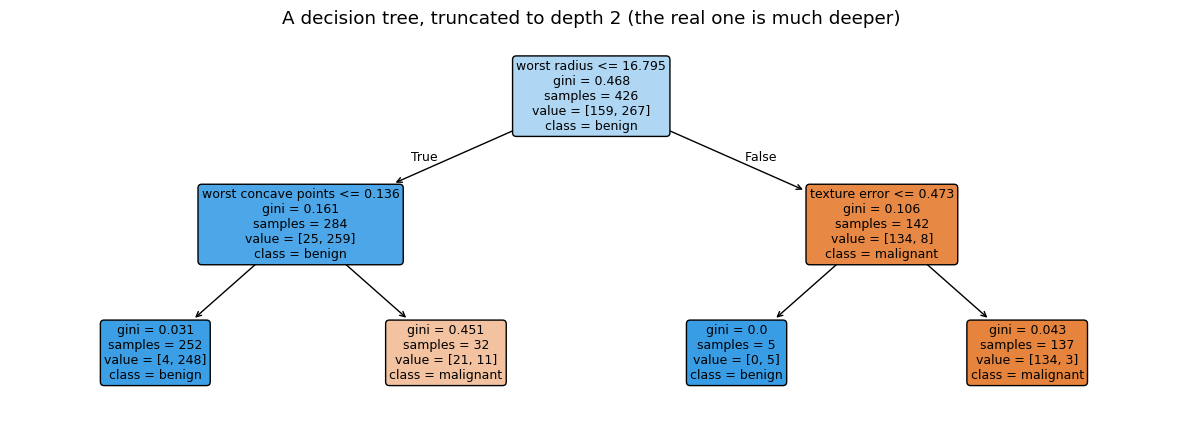

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = evaluate(DecisionTreeClassifier(random_state=RANDOM_STATE), "Decision Tree (default)")

# Plot the first 2 nodes of the tree
plt.figure(figsize=(15, 5))
plot_tree(DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE).fit(X_train, y_train),
          feature_names=X.columns, class_names=["malignant", "benign"],
          filled=True, rounded=True, fontsize=9)
plt.title("A decision tree, truncated to depth 2 (the real one is much deeper)")
plt.show()

## 3.1 🧪 Overfitting: the depth curve
The classic picture — training accuracy marches to 1.0 while test accuracy plateaus and then decays.

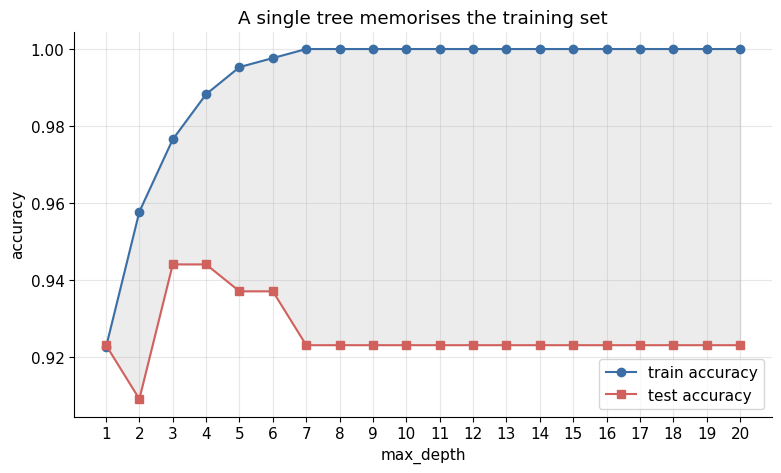

In [ ]:
depths = range(1, 21)
train_scores, test_scores = [], []

# Looping through tree depths 1-21, and appending the train and test scores for each to the lists.
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(X_train, y_train)
    train_scores.append(t.score(X_train, y_train))
    test_scores.append(t.score(X_test, y_test))

# Plot the traing and test scores from the lists
plt.figure(figsize=(9, 5))
plt.plot(depths, train_scores, "o-", label="train accuracy", color="#3b6ea5")
plt.plot(depths, test_scores, "s-", label="test accuracy", color="#d1615d")

# variance
plt.fill_between(depths, test_scores, train_scores, alpha=0.15, color="grey")

plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.xticks(list(depths))
plt.title("A single tree memorises the training set")
plt.legend(); plt.show()

## 3.2 The instability demo (this is *the* motivation for bagging)

We train **12 trees**, each on a different random 80% of the training data.
Same algorithm, same hyper-parameters — only the rows change.

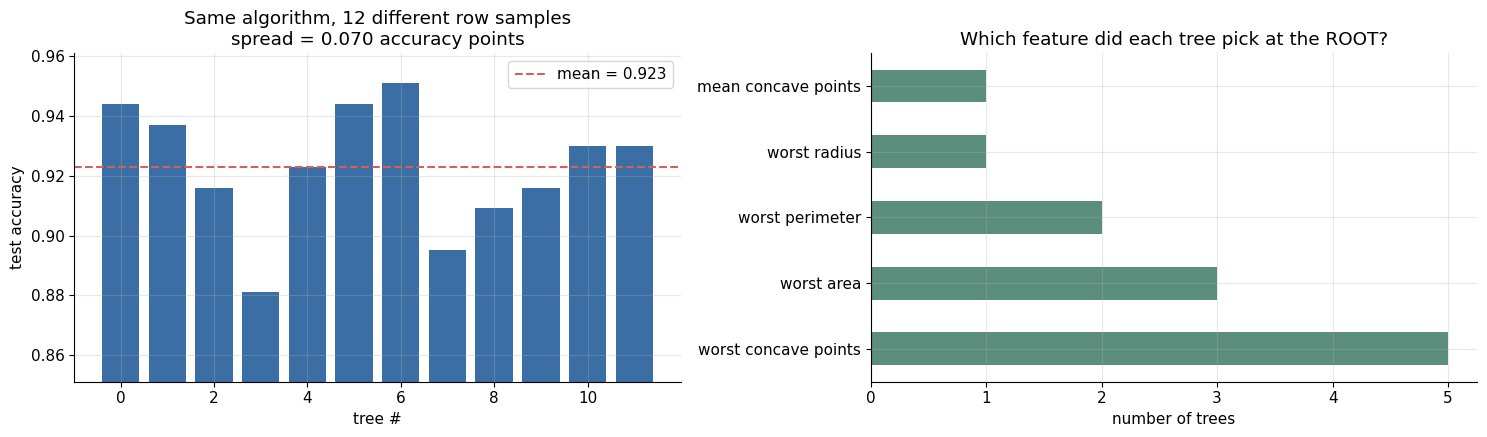

In [ ]:
root_features, accs = [], []

# train 12 tress with different random 80% of the data.
for seed in range(12):
    Xs, _, ys, _ = train_test_split(X_train, y_train, train_size=0.8,
                                    random_state=seed, stratify=y_train)
    t = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xs, ys)
    # append features and accuracies to list.
    root_features.append(X.columns[t.tree_.feature[0]])
    accs.append(t.score(X_test, y_test))

# plot accuracies
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
axes[0].bar(range(12), accs, color="#3b6ea5")
axes[0].set_ylim(min(accs) - 0.03, max(accs) + 0.01)
axes[0].axhline(np.mean(accs), color="#d1615d", ls="--", label=f"mean = {np.mean(accs):.3f}")
axes[0].set_xlabel("tree #"); axes[0].set_ylabel("test accuracy")
axes[0].set_title(f"Same algorithm, 12 different row samples\nspread = {max(accs)-min(accs):.3f} accuracy points")
axes[0].legend()

# plot features
pd.Series(root_features).value_counts().plot(kind="barh", ax=axes[1], color="#5b8e7d")
axes[1].set_title("Which feature did each tree pick at the ROOT?")
axes[1].set_xlabel("number of trees")
plt.tight_layout(); plt.show()

💡 **Takeaway 2:** the trees disagree about something as fundamental as *the very first question to ask*.
Individually that instability is a bug. Collectively, **it is the diversity we need** — averaging 12 noisy
but unbiased estimates cancels the noise. That is bagging, and we build it in Section 5.

---
# 4. Voting ensembles

The simplest ensemble: train **different algorithms** on the **same data** and combine their outputs.

| Type | How | When |
|------|-----|------|
| **Hard voting** | majority of predicted *labels* | models only output labels |
| **Soft voting** | average of predicted *probabilities* | models are calibrated → usually **better** |

Soft voting usually wins because a model that is 95% sure counts more than one that is 51% sure.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# NOTE: distance/margin based models need scaling -> wrap them in a pipeline
clf_lr  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))
clf_svm = make_pipeline(StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE))
clf_knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7))
clf_dt  = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)

base = [("logreg", clf_lr), ("svm", clf_svm), ("knn", clf_knn), ("tree", clf_dt)]

print("--- individual members ---")
for name, m in base:
    evaluate(m, f"  {name}", store=False)

print("\n--- ensembles ---")
# Hard Voting: The ensemble predicts the class that received the most 'votes' from the individual models.
evaluate(VotingClassifier(base, voting="hard"), "Voting (hard)")

# Soft Voting: The ensemble averages the predicted probabilities from each model and picks the class with the highest average.
# This often performs better because it accounts for how confident each model is.
evaluate(VotingClassifier(base, voting="soft"), "Voting (soft)")

--- individual members ---
  logreg                     acc=0.9860  auc=0.9977  cv=0.9789 (+/-0.0088)  0.03s
  svm                        acc=0.9790  auc=0.9969  cv=0.9671 (+/-0.0047)  0.04s
  knn                        acc=0.9790  auc=0.9923  cv=0.9648 (+/-0.0129)  0.01s
  tree                       acc=0.9371  auc=0.9186  cv=0.9272 (+/-0.0216)  0.01s

--- ensembles ---
Voting (hard)                acc=0.9860  auc=nan  cv=0.9718 (+/-0.0057)  0.07s
Voting (soft)                acc=0.9720  auc=0.9960  cv=0.9789 (+/-0.0047)  0.10s


VotingClassifier(estimators=[('logreg',
                              Pipeline(steps=[('standardscaler',
                                               StandardScaler()),
                                              ('logisticregression',
                                               LogisticRegression(max_iter=5000,
                                                                  random_state=42))])),
                             ('svm',
                              Pipeline(steps=[('standardscaler',
                                               StandardScaler()),
                                              ('svc',
                                               SVC(probability=True,
                                                   random_state=42))])),
                             ('knn',
                              Pipeline(steps=[('standardscaler',
                                               StandardScaler()),
                                              ('kneighborsclassifier',
                                               KNeighborsClassifier(n_neighbors=7))])),
                             ('tree',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42))],
                 voting='soft')

In [ ]:
# Creating the ensemble object manually
ensemble = VotingClassifier(estimators=base, voting='soft')

# 1. Fitting it like a normal model
ensemble.fit(X_train, y_train)

# 2. Getting predictions directly
y_pred = ensemble.predict(X_test)

# 3. Using the built-in score method (returns accuracy by default)
accuracy = ensemble.score(X_test, y_test)

print(f"The ensemble's direct accuracy score: {accuracy:.4f}")

The ensemble's direct accuracy score: 0.9720


## 4.1 Seeing the decision boundary smooth out
Two features only, so we can draw it. Watch how each model gets the shape *slightly* wrong in a
*different* place, and how the vote averages those errors away.

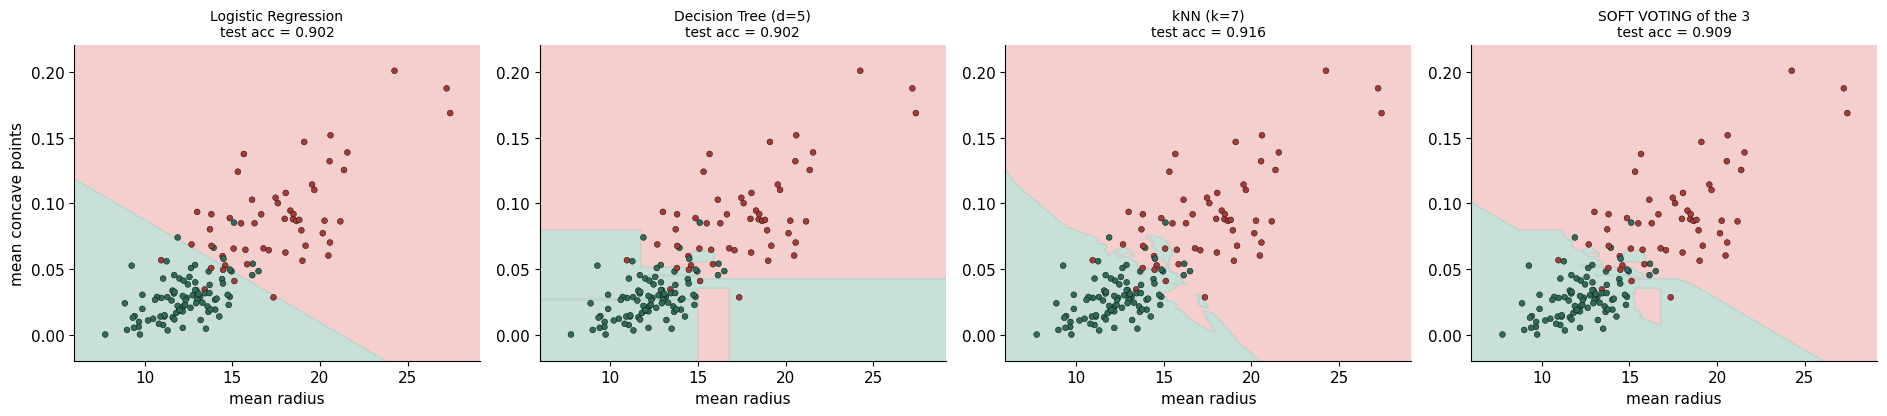

In [ ]:
from matplotlib.colors import ListedColormap

feat = ["mean radius", "mean concave points"]
X2 = X[feat].values
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y, test_size=0.25,
                                              random_state=RANDOM_STATE, stratify=y)

models2 = [
    ("Logistic Regression", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))),
    ("Decision Tree (d=5)", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
    ("kNN (k=7)",           make_pipeline(StandardScaler(), KNeighborsClassifier(7))),
    ("SOFT VOTING of the 3", VotingClassifier(
        [("lr", make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))),
         ("dt", DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)),
         ("kn", make_pipeline(StandardScaler(), KNeighborsClassifier(7)))], voting="soft")),
]

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min()-1, X2[:, 0].max()+1, 300),
                     np.linspace(X2[:, 1].min()-.02, X2[:, 1].max()+.02, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
cmap = ListedColormap(["#f2c4c2", "#bcd9cf"])

fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
for ax, (name, m) in zip(axes, models2):
    m.fit(X2_tr, y2_tr)
    Z = m.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=cmap)
    ax.scatter(X2_te[:, 0], X2_te[:, 1], c=y2_te, cmap=ListedColormap(["#a63a35", "#2f6b57"]),
               s=18, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{name}\ntest acc = {m.score(X2_te, y2_te):.3f}", fontsize=10)
    ax.set_xlabel(feat[0]); ax.grid(False)
axes[0].set_ylabel(feat[1])
plt.tight_layout(); plt.show()

💡 **Takeaway 3:** voting needs **diverse and comparably good** members. Adding a model that is
much worse than the rest will *drag the ensemble down* — try replacing the SVM with
`DummyClassifier()` and re-running to prove it to yourself.

---
# 5. Bagging (Bootstrap AGGregatING)

**Algorithm (Breiman, 1996):**
1. Draw *B* bootstrap samples — sample **N rows with replacement** from a training set of N rows.
2. Train one model per sample, **fully grown** (low bias, high variance).
3. Predict by averaging (regression) or majority vote (classification).

## 5.1 What does a bootstrap sample actually contain?

The probability a given row is **never** picked in N draws is $(1-\frac{1}{N})^N \to e^{-1} \approx 0.368$.

So each bootstrap sample contains ≈ **63.2%** of the unique rows, and the remaining **36.8%** are
"out-of-bag" (OOB) — a **free validation set** for that particular tree.

**Bagging** : Train many models independently using different random subsets of the training data.

# **Example**

***Dataset:*** A B C D E

***Tree 1 trains on:*** A B B D E

Sample C was not used, so C is OOB for Tree 1.

Now use Tree 1 to predict C. Since the tree never saw C during training, this acts like testing on unseen data.

Repeat this for every tree and every sample:

Each sample is predicted only by the trees that didn't train on it.
Combine those predictions (majority vote or average).
Compare with the true label to calculate the OOB error.

# **Why is it useful?**

✅ No separate validation set needed.

✅ Uses all the data for training.

✅ Gives a reliable estimate of model performance "for free."

## 5.2 Bagging in scikit-learn

`BaggingClassifier` wraps **any** estimator — trees, SVMs, kNN, anything.
Key arguments:

| Argument | Meaning |
|---|---|
| `estimator` | the base model (default: decision tree) |
| `n_estimators` | how many models |
| `max_samples` | rows per model (1.0 = N rows with replacement) |
| `max_features` | columns per model (**this is "random subspace" bagging**) |
| `bootstrap` | `True` = with replacement |
| `oob_score=True` | compute the free out-of-bag validation score |
| `n_jobs=-1` | use all CPU cores — bagging is **embarrassingly parallel** |

In [ ]:
from sklearn.ensemble import BaggingClassifier

evaluate(DecisionTreeClassifier(random_state=RANDOM_STATE), "Decision Tree (default)", store=False)

bag = evaluate(BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=200, max_samples=1.0, bootstrap=True,
        oob_score=True, n_jobs=-1, random_state=RANDOM_STATE),
    "Bagging (200 trees)")

print(f"\nOut-of-bag score (free validation, no data held out): {bag.oob_score_:.4f}")

Decision Tree (default)      acc=0.9231  auc=0.9234  cv=0.9248 (+/-0.0161)  0.02s
Bagging (200 trees)          acc=0.9510  auc=0.9933  cv=0.9554 (+/-0.0187)  4.02s

Out-of-bag score (free validation, no data held out): 0.9554


## 5.3 🧪 How many estimators do I need?
Bagging **cannot overfit by adding more trees** — the curve flattens, it does not turn back up.
More trees only cost you time. (Boosting behaves very differently — see Section 8.)

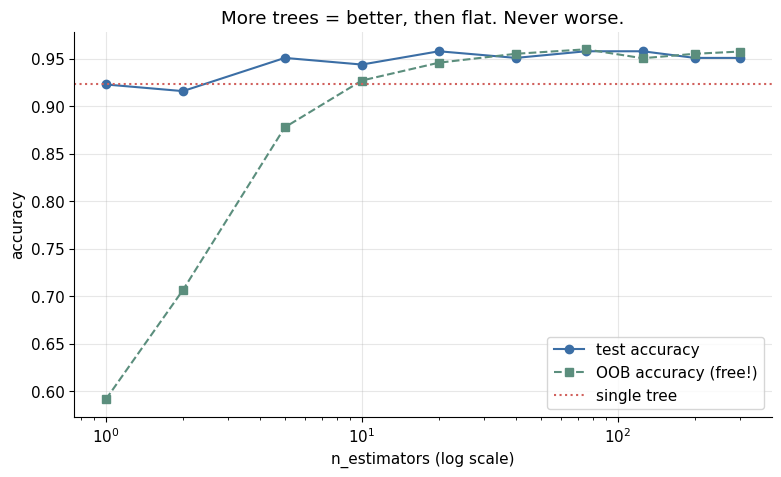

In [ ]:
ns = [1, 2, 5, 10, 20, 40, 75, 125, 200, 300]
test_acc, oob_acc = [], []
for n in ns:
    b = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                          n_estimators=n, oob_score=True, n_jobs=-1,
                          random_state=RANDOM_STATE).fit(X_train, y_train)
    test_acc.append(b.score(X_test, y_test))
    oob_acc.append(b.oob_score_)

plt.figure(figsize=(9, 5))
plt.plot(ns, test_acc, "o-", label="test accuracy", color="#3b6ea5")
plt.plot(ns, oob_acc, "s--", label="OOB accuracy (free!)", color="#5b8e7d")
plt.axhline(test_acc[0], color="#d1615d", ls=":", label="single tree")
plt.xscale("log"); plt.xlabel("n_estimators (log scale)"); plt.ylabel("accuracy")
plt.title("More trees = better, then flat. Never worse.")
plt.legend(); plt.show()

💡 **Takeaway 4:** bagging leaves **bias unchanged** and divides **variance** by roughly the number of
*uncorrelated* models. Which raises the obvious question — how do we make the trees *less correlated*?

---
# 6. Random Forest

Random Forest = **bagging + one extra trick**:

> At **every split**, consider only a **random subset of `max_features` columns**.

Why this matters: in plain bagging, if one feature is dominant (`worst perimeter` here), *every* tree
splits on it first and the trees end up highly correlated — so averaging helps less than it could.
Forcing each split to ignore most columns **decorrelates** the trees.

The variance of an average of B models with pairwise correlation ρ is:

$$\text{Var} = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

The second term vanishes as B grows; **only lowering ρ can reduce the first term**. That is exactly what
`max_features` buys you — a small increase in each tree's bias for a large drop in ρ.

| Parameter | Typical value | Effect |
|---|---|---|
| `n_estimators` | 100–1000 | more = better then flat, costs time |
| `max_features` | `"sqrt"` (clf) / 1.0 (reg) | ↓ = more decorrelation, more bias |
| `max_depth` | `None` | leave trees deep — variance is handled by averaging |
| `min_samples_leaf` | 1–5 | raise it for noisy data |
| `class_weight` | `"balanced"` | for imbalanced targets |
| `n_jobs` | `-1` | parallel |

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = evaluate(RandomForestClassifier(n_estimators=300, max_features="sqrt",
                                     oob_score=True, n_jobs=-1, random_state=RANDOM_STATE),
              "Random Forest (300)")
print(f"\nOOB score: {rf.oob_score_:.4f}")

Random Forest (300)          acc=0.9580  auc=0.9949  cv=0.9578 (+/-0.0175)  2.50s

OOB score: 0.9624


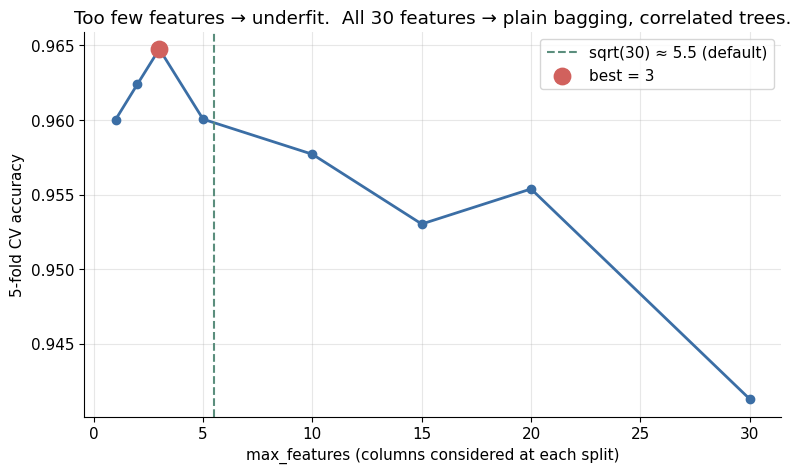

In [ ]:
# 🧪 does the extra randomness actually help? sweep max_features
n_feats = X_train.shape[1]
options = [1, 2, 3, 5, int(np.sqrt(n_feats)), 10, 15, 20, 30]
options = sorted(set(options))
scores = []
for mf in options:
    s = cross_val_score(RandomForestClassifier(n_estimators=200, max_features=mf, n_jobs=-1,
                                               random_state=RANDOM_STATE),
                        X_train, y_train, cv=5).mean()
    scores.append(s)

plt.figure(figsize=(9, 5))
plt.plot(options, scores, "o-", color="#3b6ea5", lw=2)
best = options[int(np.argmax(scores))]
plt.axvline(np.sqrt(n_feats), color="#5b8e7d", ls="--", label=f"sqrt(30) ≈ {np.sqrt(n_feats):.1f} (default)")
plt.scatter([best], [max(scores)], color="#d1615d", s=140, zorder=5, label=f"best = {best}")
plt.xlabel("max_features (columns considered at each split)")
plt.ylabel("5-fold CV accuracy")
plt.title("Too few features → underfit.  All 30 features → plain bagging, correlated trees.")
plt.legend(); plt.show()

## 6.1 Feature importance — and the trap everyone falls into

Two ways to ask "which features matter?":

| Method | How it works | Watch out |
|---|---|---|
| **`feature_importances_`** (MDI / Gini) | total impurity decrease from splits on that feature, averaged over trees | **biased toward high-cardinality / continuous features**; computed on *training* data |
| **Permutation importance** | shuffle one column in the *test* set, measure the drop in score | slower, but honest — and reflects the metric you care about |

⚠️ **Both are misleading when features are correlated** (and ours are — see the heat map in Section 2).
If two columns carry the same signal, the model uses one and the other looks worthless.

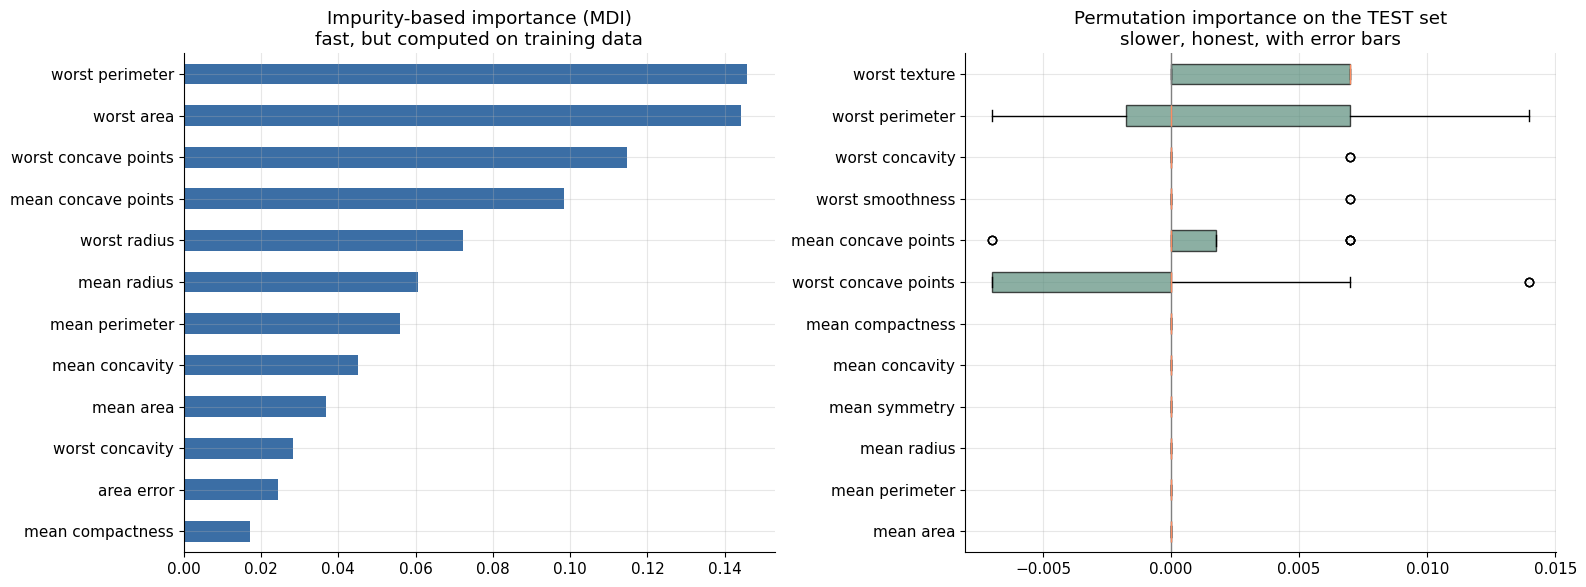

In [ ]:
from sklearn.inspection import permutation_importance

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

perm = permutation_importance(rf, X_test, y_test, n_repeats=20,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=X.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
imp.head(12)[::-1].plot(kind="barh", ax=axes[0], color="#3b6ea5")
axes[0].set_title("Impurity-based importance (MDI)\nfast, but computed on training data")

order = perm_s.head(12).index[::-1]
axes[1].boxplot([perm.importances[X.columns.get_loc(c)] for c in order],
                vert=False, labels=order, patch_artist=True,
                boxprops=dict(facecolor="#5b8e7d", alpha=0.7))
axes[1].axvline(0, color="grey", lw=1)
axes[1].set_title("Permutation importance on the TEST set\nslower, honest, with error bars")
plt.tight_layout(); plt.show()

---
# 7. Extra Trees (Extremely Randomised Trees)

One more turn of the randomness dial:

| | Random Forest | Extra Trees |
|---|---|---|
| Rows | bootstrap sample | **whole training set** (by default) |
| Columns per split | random subset | random subset |
| Split threshold | **best** possible cut point | **random** cut points, best of those |
| Speed | fast | **faster** (no threshold search) |
| Bias / variance | low bias, low variance | slightly ↑ bias, ↓↓ variance |

Extra Trees is often a free win on noisy data — always worth a 30-second try.

In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

evaluate(ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
         "Extra Trees (300)")

Extra Trees (300)            acc=0.9650  auc=0.9952  cv=0.9695 (+/-0.0120)  1.22s


ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42)

---
# 8. Boosting: AdaBoost

Everything so far was **parallel and independent**. Boosting is **sequential and adaptive**:

1. Train a weak learner (a *stump*: a tree of depth 1) on equally weighted data.
2. **Increase the weight** of every misclassified row.
3. Train the next stump on the reweighted data — it is forced to focus on the hard cases.
4. Give each stump a say $\alpha_m = \frac{1}{2}\ln\frac{1-\varepsilon_m}{\varepsilon_m}$ proportional to how good it is.
5. Final prediction: $\text{sign}\left(\sum_m \alpha_m h_m(x)\right)$

Let's implement the weighting loop by hand so you can *see* the sample weights grow.

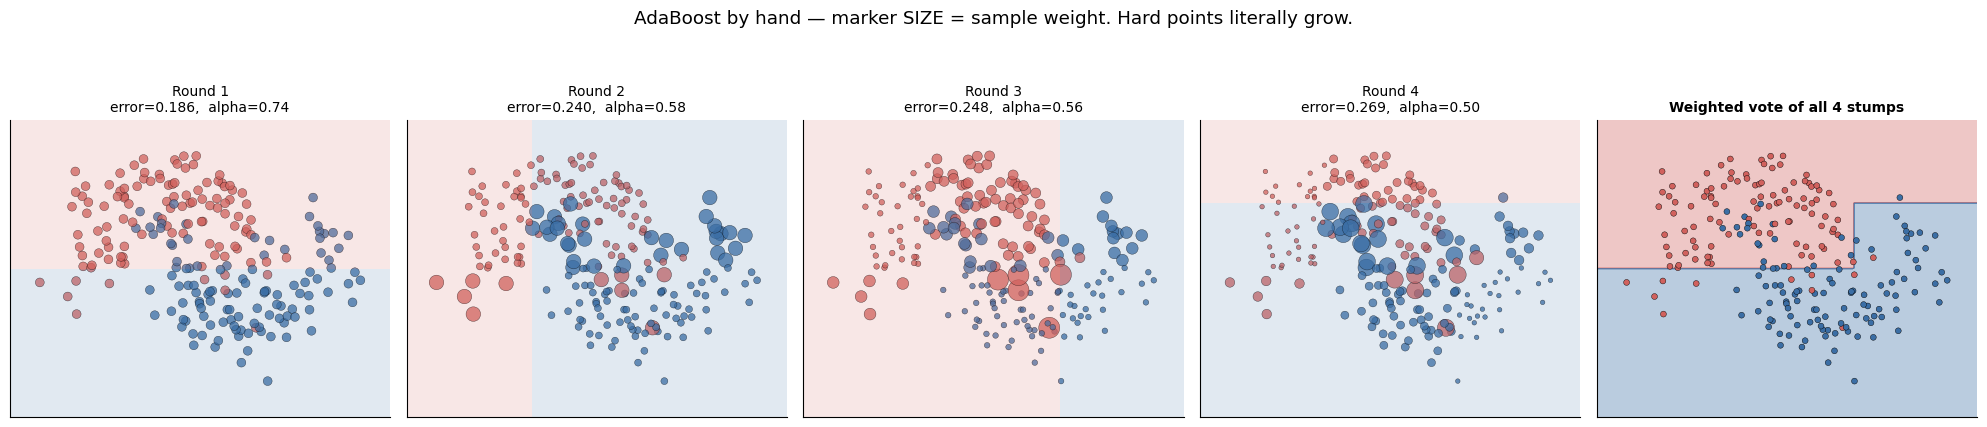

In [ ]:
from sklearn.datasets import make_moons

Xm, ym = make_moons(n_samples=220, noise=0.28, random_state=RANDOM_STATE)
ym_pm = np.where(ym == 0, -1, 1)                 # AdaBoost maths uses labels in {-1, +1}

n_iter = 4
w = np.ones(len(Xm)) / len(Xm)                   # step 1: equal weights
stumps, alphas = [], []

fig, axes = plt.subplots(1, n_iter + 1, figsize=(20, 4))
for m in range(n_iter):
    stump = DecisionTreeClassifier(max_depth=1).fit(Xm, ym_pm, sample_weight=w)
    pred = stump.predict(Xm)
    miss = (pred != ym_pm)
    err = np.dot(w, miss) / w.sum()                              # weighted error
    alpha = 0.5 * np.log((1 - err) / max(err, 1e-10))            # this stump's vote strength
    stumps.append(stump); alphas.append(alpha)

    ax = axes[m]
    ax.scatter(Xm[:, 0], Xm[:, 1], s=w * 9000, c=ym, cmap=ListedColormap(["#d1615d", "#3b6ea5"]),
               alpha=0.75, edgecolor="k", linewidth=0.3)
    xx2, yy2 = np.meshgrid(np.linspace(Xm[:,0].min()-.4, Xm[:,0].max()+.4, 200),
                           np.linspace(Xm[:,1].min()-.4, Xm[:,1].max()+.4, 200))
    Z = stump.predict(np.c_[xx2.ravel(), yy2.ravel()]).reshape(xx2.shape)
    ax.contourf(xx2, yy2, Z, alpha=0.15, cmap=ListedColormap(["#d1615d", "#3b6ea5"]))
    ax.set_title(f"Round {m+1}\nerror={err:.3f},  alpha={alpha:.2f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

    w = w * np.exp(-alpha * ym_pm * pred)      # step 2: misclassified -> weight UP
    w = w / w.sum()

# combined prediction of all 4 stumps
Z = np.sign(sum(a * s.predict(np.c_[xx2.ravel(), yy2.ravel()]) for a, s in zip(alphas, stumps)))
axes[-1].contourf(xx2, yy2, Z.reshape(xx2.shape), alpha=0.35,
                  cmap=ListedColormap(["#d1615d", "#3b6ea5"]))
axes[-1].scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap=ListedColormap(["#d1615d", "#3b6ea5"]),
                 s=18, edgecolor="k", linewidth=0.3)
axes[-1].set_title("Weighted vote of all 4 stumps", fontsize=10, fontweight="bold")
axes[-1].set_xticks([]); axes[-1].set_yticks([]); axes[-1].grid(False)
plt.suptitle("AdaBoost by hand — marker SIZE = sample weight. Hard points literally grow.", y=1.06)
plt.tight_layout(); plt.show()

## 8.1 AdaBoost in scikit-learn, and the *shape* of a boosting curve
Note the contrast with Section 5.3: bagging's curve is flat after a while;
boosting **keeps improving and can eventually overfit**. `staged_predict` lets us watch it happen.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

ada = evaluate(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                  n_estimators=300, learning_rate=0.5,
                                  random_state=RANDOM_STATE),
               "AdaBoost (300 stumps)")

# teaser for Notebook 2
evaluate(GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3,
                                    random_state=RANDOM_STATE),
         "Gradient Boosting (200)")

AdaBoost (300 stumps)        acc=0.9580  auc=0.9874  cv=0.9718 (+/-0.0120)  1.39s
Gradient Boosting (200)      acc=0.9580  auc=0.9950  cv=0.9601 (+/-0.0190)  1.60s


GradientBoostingClassifier(n_estimators=200, random_state=42)

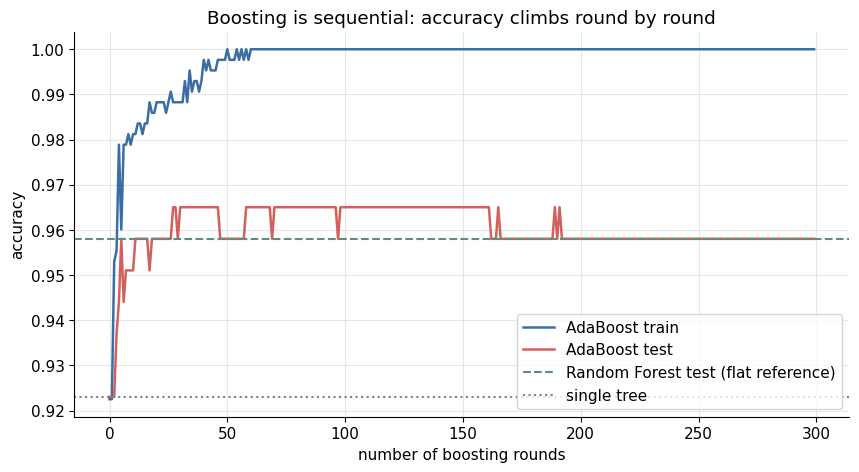

In [ ]:
staged_test  = [accuracy_score(y_test,  p) for p in ada.staged_predict(X_test)]
staged_train = [accuracy_score(y_train, p) for p in ada.staged_predict(X_train)]

plt.figure(figsize=(10, 5))
plt.plot(staged_train, label="AdaBoost train", color="#3b6ea5", lw=1.8)
plt.plot(staged_test,  label="AdaBoost test",  color="#d1615d", lw=1.8)
plt.axhline(RESULTS["Random Forest (300)"]["test_accuracy"], color="#5b8e7d", ls="--",
            label="Random Forest test (flat reference)")
plt.axhline(RESULTS["Decision Tree (default)"]["test_accuracy"], color="grey", ls=":",
            label="single tree")
plt.xlabel("number of boosting rounds"); plt.ylabel("accuracy")
plt.title("Boosting is sequential: accuracy climbs round by round")
plt.legend(loc="lower right"); plt.show()

💡 **Takeaway 5 — the one-slide summary of bagging vs boosting:**

| | Bagging / RF | Boosting |
|---|---|---|
| Base learners | **deep** trees (low bias, high variance) | **shallow** trees / stumps (high bias) |
| Trained | independently, **in parallel** | sequentially, each on the previous errors |
| Reduces | **variance** | **bias** (and variance, with shrinkage) |
| More estimators | never hurts, just flattens | **can overfit** → needs early stopping |
| Noise / outliers | robust | **sensitive** (keeps chasing hard points) |
| Tuning effort | low — works out of the box | higher — lr × n_estimators × depth |
| Typical accuracy on tabular data | very good | **usually the winner** |

Notebook 2 takes the right-hand column apart in detail.

---
# 9. Stacking (Stacked Generalisation)

Voting combines models with a **fixed rule** (mean / majority). Stacking asks: why not **learn** the
combination rule?

1. Split the training data into K folds.
2. For each base model, produce **out-of-fold predictions** for every training row.
   *(This is the crucial step — using in-fold predictions would leak and the meta-model would
   simply trust whichever base model overfits hardest.)*
3. Those predictions become the feature matrix for a **meta-model** (usually something simple:
   logistic regression or a shallow GBM).
4. At predict time, base models are refit on all the data and feed the meta-model.

scikit-learn's `StackingClassifier` does the out-of-fold plumbing for you via `cv=`.

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ("rf",   RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    ("et",   ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    ("gb",   GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE)),
    ("svm",  make_pipeline(StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE))),
    ("knn",  make_pipeline(StandardScaler(), KNeighborsClassifier(7))),
]

stack = evaluate(StackingClassifier(
        estimators=estimators,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5, n_jobs=-1, passthrough=False),
    "Stacking (5 base + LR meta)")

Stacking (5 base + LR meta)  acc=0.9650  auc=0.9971  cv=0.9765 (+/-0.0074)  14.77s


In [ ]:
# What did the meta-model learn? Its coefficients = how much it trusts each base model.
coefs = pd.Series(stack.final_estimator_.coef_[0], index=[n for n, _ in estimators])
plt.figure(figsize=(8, 4.5))
colors = ["#5b8e7d" if c > 0 else "#d1615d" for c in coefs]
coefs.sort_values().plot(kind="barh", color=colors)
plt.axvline(0, color="k", lw=1)
plt.title("Meta-learner coefficients: whom does the ensemble trust?")
plt.xlabel("logistic-regression weight on that base model's probability")
plt.show()

print("Negative weights are normal and useful — the meta-model is learning a *correction*,")
print("not a popularity contest.")

⚠️ **Stacking practicalities**
- Cost = (K+1) × the cost of every base model. Budget for it.
- Keep the meta-model **simple** (logistic / ridge). A complex meta-model overfits the K×M prediction matrix.
- `passthrough=True` also feeds the *original features* to the meta-model — sometimes helps, always slower.
- Diversity beats raw strength: five near-identical GBMs stack worse than a GBM + a kNN + a linear model.

---
# 10. End-to-end on a messy real-world dataset

Everything so far used clean numeric data. Real data has **text columns, missing values and
imbalance**. We now use the **Adult / Census Income** dataset (UCI ML Repository):
predict whether a person earns **> \$50K/year** from 14 demographic attributes.

This is where `Pipeline` + `ColumnTransformer` become non-negotiable — they keep the preprocessing
**inside** the cross-validation loop, so no information leaks from the validation fold.

In [ ]:
URL = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/adult-all.csv"
cols = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
        "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
        "hours_per_week", "native_country", "income"]

adult = pd.read_csv(URL, header=None, names=cols, na_values=" ?", skipinitialspace=True)
adult["income"] = (adult["income"].astype(str).str.strip() == ">50K").astype(int)
adult = adult.drop(columns=["fnlwgt", "education"])     # fnlwgt is a survey weight; education duplicates education_num

# subsample to keep the workshop snappy — remove this line at home
adult = adult.sample(12000, random_state=RANDOM_STATE).reset_index(drop=True)

print("Shape:", adult.shape)
print("Positive class (>50K):", f"{adult['income'].mean():.1%}")
print("\nMissing values per column:")
print(adult.isna().sum()[adult.isna().sum() > 0])
adult.head()

Shape: (12000, 13)
Positive class (>50K): 24.3%

Missing values per column:
Series([], dtype: int64)


,age,workclass,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,18,Private,9,Never-married,Other-service,Not-in-family,White,Male,0,0,20,United-States,0
1,17,Private,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,0
2,25,Local-gov,9,Never-married,Handlers-cleaners,Other-relative,Black,Male,0,0,40,United-States,0
3,20,Private,10,Never-married,Sales,Own-child,White,Female,0,0,30,United-States,0
4,47,Private,9,Never-married,Machine-op-inspct,Unmarried,Amer-Indian-Eskimo,Male,0,0,56,Puerto-Rico,0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
adult["income"].map({0: "<=50K", 1: ">50K"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#3b6ea5", "#d1615d"], rot=0)
axes[0].set_title("Imbalanced target (~24% positive)")

sns.histplot(data=adult, x="age", hue="income", bins=30, ax=axes[1], element="step")
axes[1].set_title("Age vs income")

(adult.groupby("education_num")["income"].mean() * 100).plot(
    kind="bar", ax=axes[2], color="#5b8e7d", rot=0)
axes[2].set_title("% earning >50K by years of education")
plt.tight_layout(); plt.show()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

Xa = adult.drop(columns="income")
ya = adult["income"]

num_cols = Xa.select_dtypes(include=np.number).columns.tolist()
cat_cols = Xa.select_dtypes(exclude=np.number).columns.tolist()
print("numeric   :", num_cols)
print("categorical:", cat_cols)

preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                      ("ohe", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xa, ya, test_size=0.25,
                                              random_state=RANDOM_STATE, stratify=ya)

In [ ]:
from sklearn.dummy import DummyClassifier

candidates = {
    "Baseline (majority)": DummyClassifier(strategy="most_frequent"),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Bagging":             BaggingClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=250, min_samples_leaf=2,
                                                  n_jobs=-1, random_state=RANDOM_STATE),
    "Extra Trees":         ExtraTreesClassifier(n_estimators=250, min_samples_leaf=2,
                                                n_jobs=-1, random_state=RANDOM_STATE),
    "AdaBoost":            AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Stacking":            StackingClassifier(
                              estimators=[("rf", RandomForestClassifier(n_estimators=150, n_jobs=-1,
                                                 random_state=RANDOM_STATE)),
                                          ("gb", GradientBoostingClassifier(n_estimators=120,
                                                 random_state=RANDOM_STATE)),
                                          ("lr", LogisticRegression(max_iter=2000))],
                              final_estimator=LogisticRegression(max_iter=2000), cv=3, n_jobs=-1),
}

adult_scores, fitted = {}, {}
for name, clf in candidates.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    t0 = time.time()
    cv = cross_val_score(pipe, Xa_tr, ya_tr, cv=3, scoring="roc_auc"
                         if name != "Baseline (majority)" else "accuracy", n_jobs=-1)
    pipe.fit(Xa_tr, ya_tr)
    fitted[name] = pipe
    adult_scores[name] = {"cv_score": cv.mean(), "cv_std": cv.std(),
                          "test_acc": pipe.score(Xa_te, ya_te),
                          "seconds": time.time() - t0}
    print(f"{name:<22} cv={cv.mean():.4f} (+/-{cv.std():.4f})  test_acc={adult_scores[name]['test_acc']:.4f}  {adult_scores[name]['seconds']:.1f}s")

adult_df = pd.DataFrame(adult_scores).T.sort_values("cv_score", ascending=False)
adult_df

In [ ]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# accuracy vs training cost
for name, row in adult_df.iterrows():
    if name == "Baseline (majority)": continue
    axes[0].scatter(row["seconds"], row["test_acc"], s=140)
    axes[0].annotate(name, (row["seconds"], row["test_acc"]),
                     textcoords="offset points", xytext=(7, 5), fontsize=9)
axes[0].set_xlabel("training time (s, 3-fold CV + final fit)")
axes[0].set_ylabel("test accuracy")
axes[0].set_title("Accuracy vs compute — the real engineering trade-off")

for name in ["Decision Tree", "Random Forest", "Gradient Boosting", "Stacking"]:
    RocCurveDisplay.from_estimator(fitted[name], Xa_te, ya_te, ax=axes[1], name=name)
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_title("ROC curves on the held-out test set")
plt.tight_layout(); plt.show()

---
# 11. Cheat sheet — which ensemble, when?

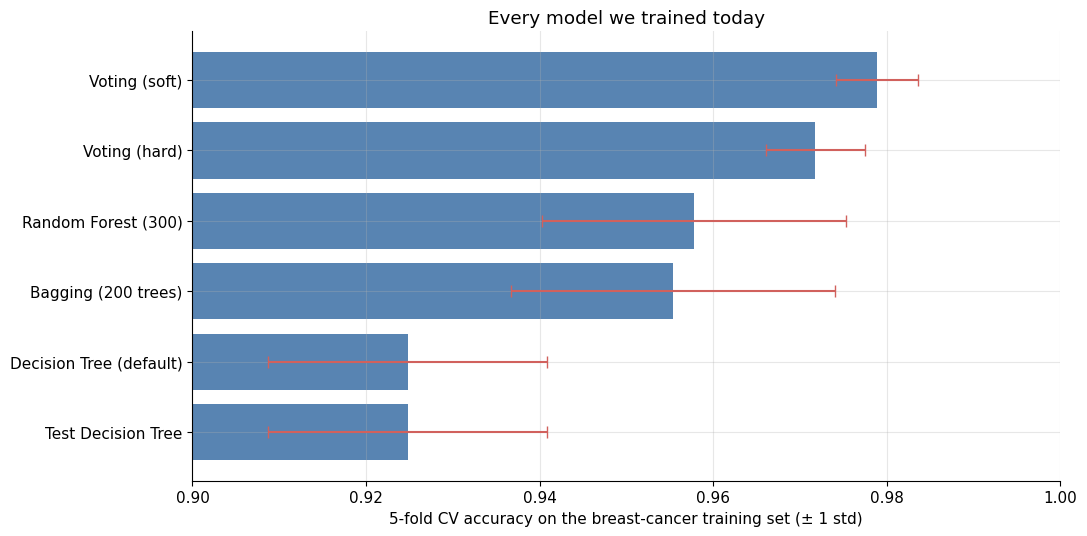

,test_accuracy,test_auc,cv_mean,cv_std,fit_time_s
Voting (hard),0.9860,NaN,0.9718,0.0057,0.0716
Voting (soft),0.9720,0.9960,0.9789,0.0047,0.1004
Random Forest (300),0.9580,0.9949,0.9578,0.0175,2.5042
Bagging (200 trees),0.9510,0.9933,0.9554,0.0187,4.0157
Decision Tree (default),0.9231,0.9234,0.9248,0.0161,0.0187
Test Decision Tree,0.9231,0.9234,0.9248,0.0161,0.0163


In [ ]:
summary = pd.DataFrame(RESULTS).T.sort_values("test_accuracy", ascending=False)
summary = summary[["test_accuracy", "test_auc", "cv_mean", "cv_std", "fit_time_s"]].round(4)

fig, ax = plt.subplots(figsize=(11, 5.5))
s = summary.sort_values("cv_mean")
ax.barh(s.index, s["cv_mean"], xerr=s["cv_std"], color="#3b6ea5", alpha=0.85,
        error_kw=dict(ecolor="#d1615d", lw=1.5, capsize=4))
ax.set_xlim(0.90, 1.0)
ax.set_xlabel("5-fold CV accuracy on the breast-cancer training set (± 1 std)")
ax.set_title("Every model we trained today")
plt.tight_layout(); plt.show()

summary

### Decision guide

| Situation | Reach for |
|---|---|
| Quick strong baseline, minimal tuning, want feature importances | **Random Forest** |
| Noisy data / lots of irrelevant features / need speed | **Extra Trees** |
| You want the best possible tabular accuracy and can tune | **Gradient Boosting → XGBoost / LightGBM** (Notebook 2) |
| Your base model overfits badly and you want to stabilise it | **Bagging** |
| You already have several good, *different* models | **Voting (soft)** → then **Stacking** |
| Kaggle-style last 0.5% | **Stacking** of diverse tuned models |
| You need interpretability / a regulator will read it | single tree, or RF + SHAP |
| Tiny dataset (< a few hundred rows) | ensembles still help, but prefer RF over boosting (less overfitting) |
| Data has strong temporal structure | ⚠️ use `TimeSeriesSplit`, never plain K-fold |

### Universal gotchas
1. **Fit preprocessing inside the pipeline**, never before the split — otherwise you leak.
2. **`n_jobs=-1`** on every parallel ensemble. Free speed.
3. `random_state` everywhere, or your results are not reproducible.
4. **More estimators never hurts bagging; it *can* hurt boosting.**
5. Impurity importances lie when features are correlated. Use permutation importance or SHAP.
6. Ensembles are **not a fix for bad data**. Fifty models trained on a leaky feature all learn the leak.

---
# 12. Exercises

Try these now — solutions are one or two lines each.

1. **Break the vote.** Add `("dummy", DummyClassifier(strategy="uniform"))` to the `VotingClassifier`
   in Section 4 and re-run. How much does one bad member cost you? Try `weights=[...]` to fix it.
2. **Bagging a different base model.** Set `estimator=KNeighborsClassifier()` in `BaggingClassifier`.
   Does bagging help as much? *Why not?* (Hint: is kNN a high-variance model?)
3. **Random subspaces.** In `BaggingClassifier`, set `bootstrap=False, max_features=0.5`.
   You have just built the "random subspace method". Compare it to Random Forest.
4. **Overfit AdaBoost on purpose.** Set `estimator=DecisionTreeClassifier(max_depth=8)` and
   `n_estimators=500`. Plot `staged_predict` again — find where test accuracy peaks and decays.
5. **Class imbalance.** On the Adult dataset, add `class_weight="balanced"` to the Random Forest.
   Compare recall on the `>50K` class before and after.
6. **Build your own stack.** Beat the Section 9 result by swapping the meta-model for
   `GradientBoostingClassifier(max_depth=2)` or by setting `passthrough=True`.

---
## Further reading
- Breiman (1996), *Bagging Predictors*; Breiman (2001), *Random Forests*
- Freund & Schapire (1997), *A decision-theoretic generalization of on-line learning* (AdaBoost)
- Wolpert (1992), *Stacked Generalization*
- scikit-learn User Guide → **Ensembles**: https://scikit-learn.org/stable/modules/ensemble.html
- *The Elements of Statistical Learning*, ch. 10 & 15 (free PDF from Stanford)

### ➡️ Next: **Notebook 2 — XGBoost & Gradient Boosting**
We open up the boosting box: gradient descent in function space, built from scratch,
then the engineering that makes XGBoost the default choice for tabular data.